# PART3_Model_comparison
Compare genomic prediction model using GBLUP/Lasso/Enet/LGBM/(RF)

In [1]:
import ast
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.training_module import train_GBLUP, GBLUP_coef, train_lightgbm, train_randomforest, train_Lasso, train_Enet

# Training models using all RILs

## Parameter tuning for Lasso, Enet, LGBM, RF
Hyperparameter tuning by Optuna using training dataset only

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5
optuna_seed=1024

Lasso_params = []
Enet_params = []
LGBM_params = []
RF_params = []
for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024)
    for i in range(CV):
        train_data_CVn = train_data[i]
        X = train_data_CVn[0]; y = train_data_CVn[1]
        Lasso_params.append([trait_name, i, tuning_Lasso(X, y)])
        Enet_params.append([trait_name, i, tuning_ElasticNet(X, y)])
        LGBM_params.append([trait_name, i, tuning_LightGBM(X, y)])
        RF_params.append([trait_name, i, tuning_RandomForest(X, y)])
    pd.DataFrame(Lasso_params).to_csv("../data/PART3_Model_comparison/Lasso_all_{}_params.csv".format(trait_name))
    pd.DataFrame(Enet_params).to_csv("../data/PART3_Model_comparison/Enet_all_{}_params.csv".format(trait_name))
    pd.DataFrame(LGBM_params).to_csv("../data/PART3_Model_comparison/LGBM_all_{}_params.csv".format(trait_name))
    pd.DataFrame(RF_params).to_csv("../data/PART3_Model_comparison/RF_all_{}_params.csv".format(trait_name))

## Train models
Train model using training dataset -> predict test dataset & check accuracy

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
genotype = "../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv"
genotype = "../data/PART1_make_Haplotype_block/test_genotype.csv"
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5

summary = []
for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    # separate test & train dataset
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)

    for i in range(CV):
        print("CV{}".format(i))
        start = time.time()
        tmp_test_data = test_data[i]
        tmp_train_data = train_data[i]

        # parameters
        LGBM_params = pd.read_csv("../data/PART3_Model_comparison/LGBM_all_{}_params.csv".format(trait_name), index_col=0)
        LGBM_params.columns = ["trait", "CV", "params"]
        LGBM_params = ast.literal_eval(LGBM_params.loc[(LGBM_params["trait"] == trait_name) & (LGBM_params["CV"] == i), "params"].values[0])        
        RF_params = pd.read_csv("../data/PART3_Model_comparison/RF_all_{}_params.csv".format(trait_name), index_col=0)
        RF_params.columns = ["trait", "CV", "params"]
        RF_params = ast.literal_eval(RF_params.loc[(RF_params["trait"] == trait_name) & (RF_params["CV"] == i), "params"].values[0])        
        Lasso_params = pd.read_csv("../data/PART3_Model_comparison/Lasso_all_{}_params.csv".format(trait_name), index_col=0)
        Lasso_params.columns = ["trait", "CV", "params"]
        Lasso_params = ast.literal_eval(Lasso_params.loc[(Lasso_params["trait"] == trait_name) & (Lasso_params["CV"] == i), "params"].values[0])
        Enet_params = pd.read_csv("../data/PART3_Model_comparison/Enet_all_{}_params.csv".format(trait_name), index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])

        # train all models
        print("GBLUP start")
        test_pred, h2, r2, acc_RIL = train_GBLUP(tmp_test_data, tmp_train_data, genotype)
        coefs = GBLUP_coef(tmp_train_data, genotype)
        summary.append([trait_name, i, "GBLUP", test_pred, r2, acc_RIL, coefs])

        print("LightGBM start")
        test_preds, r2, acc_RIL, feature_importances = train_lightgbm(tmp_test_data, tmp_train_data, CV, LGBM_params)
        summary.append([trait_name, i, "LGBM", test_preds, r2, acc_RIL, feature_importances])

        print("RandomForest start")
        test_pred, r2, acc_RIL, feature_importance = train_randomforest(tmp_test_data, tmp_train_data, CV, RF_params)
        summary.append([trait_name, i, "RF", test_pred, r2, acc_RIL, feature_importance])

        print("Lasso start")
        test_pred, r2, acc_RIL, coefs = train_Lasso(tmp_test_data, tmp_train_data, Lasso_params)
        summary.append([trait_name, i, "Lasso", test_pred, r2, acc_RIL, coefs])

        print("ElasticNet start")
        test_pred, r2, acc_RIL, coefs = train_Enet(tmp_test_data, tmp_train_data, Enet_params)
        summary.append([trait_name, i, "Enet", test_pred, r2, acc_RIL, coefs])
        
        print(time.time() - start)

with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

## check accuracy of all models for each trait & RILs

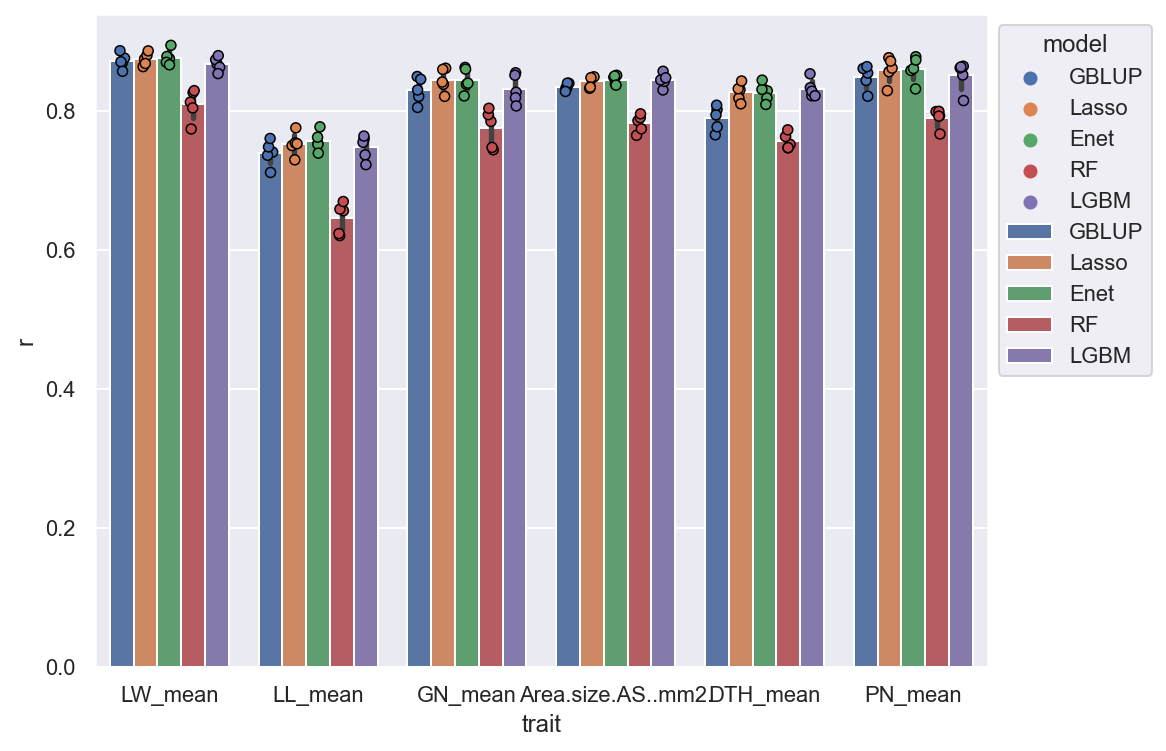

In [2]:
bar_data = []
for trait_name in ["LW_mean", "LL_mean", "GN_mean", "Area.size.AS..mm2.", "DTH_mean", "PN_mean"]:
    with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for model in ["GBLUP", "Lasso", "Enet", "RF", "LGBM"]:
        for CV in range(5):
            bar_data.append([trait_name, model, summary[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 2] == model) & (summary.iloc[:, 1] == CV)].iloc[:, 4].values[0]])
bar_data = pd.DataFrame(bar_data)
bar_data.columns = ["trait", "model", "r"]
plt.figure(figsize=(8,6))
ax = sns.barplot(x="trait", y="r", hue="model", data=bar_data)
sns.stripplot(x="trait", y="r", hue="model", data=bar_data, dodge=True, edgecolor="black", linewidth=.75, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()